# NBA GAME CLASSIFICATION TASKS
## MODULE: Support Vector Machines (SVM)
**Log: Data Scientist / ML Engineer**

Implementation of a Support Vector Classifier to establish an optimal hyperplane for game outcome prediction. Focus on kernel performance and regularization parameters.

## DEPS


In [2]:
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('All packages installed successfully!')

All packages installed successfully!


## FETCH DATA


In [3]:
import os
import subprocess
import sys

if not os.path.exists('games.csv'):
    print('games.csv not found. Downloading dataset...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
    import kagglehub
    path = kagglehub.dataset_download('nathanlauga/nba-games')
    print('Dataset downloaded to:', path)
    # Copy games.csv to current directory
    import shutil
    for root, dirs, files in os.walk(path):
        for file in files:
            if file == 'games.csv':
                shutil.copy2(os.path.join(root, file), 'games.csv')
                print('games.csv copied to current directory!')
                break
else:
    print('games.csv already exists. Skipping download.')

games.csv already exists. Skipping download.


## IMPORTS


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## DATA CLEANING / HEAD


In [5]:
df = pd.read_csv('games.csv')
print('Shape:', df.shape)
df.head()

Shape: (26651, 21)


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [6]:
print('Missing values:')
print(df.isnull().sum())
df.describe()

Missing values:
GAME_DATE_EST        0
GAME_ID              0
GAME_STATUS_TEXT     0
HOME_TEAM_ID         0
VISITOR_TEAM_ID      0
SEASON               0
TEAM_ID_home         0
PTS_home            99
FG_PCT_home         99
FT_PCT_home         99
FG3_PCT_home        99
AST_home            99
REB_home            99
TEAM_ID_away         0
PTS_away            99
FG_PCT_away         99
FT_PCT_away         99
FG3_PCT_away        99
AST_away            99
REB_away            99
HOME_TEAM_WINS       0
dtype: int64


,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.665100e+04,2.665100e+04,2.665100e+04,26651.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26651.000000
mean,2.175487e+07,1.610613e+09,1.610613e+09,2012.113879,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.587032
std,5.570189e+06,8.638670e+00,8.659299e+00,5.587031,8.638670e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659299e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.492376
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070001e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120076e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180005e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


## SCALING & SPLIT


Clean dataset shape: (26552, 11)
Home Win Rate: 58.92%


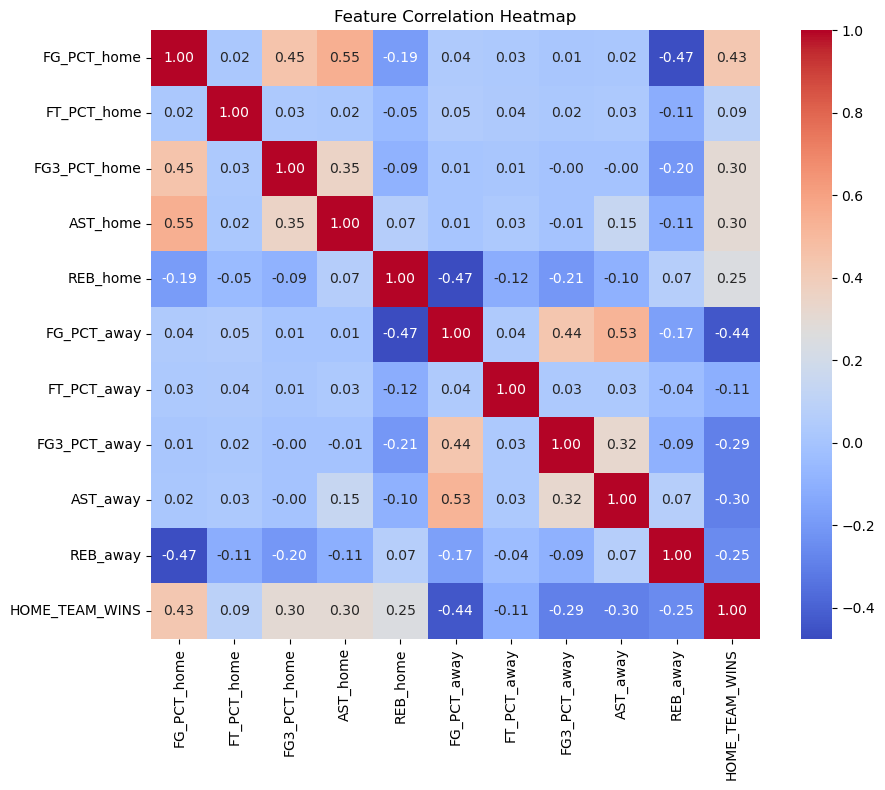

In [7]:
features = [
    'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home',
    'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away'
]
target = 'HOME_TEAM_WINS'

df_clean = df[features + [target]].dropna()
print(f'Clean dataset shape: {df_clean.shape}')
print(f'Home Win Rate: {df_clean[target].mean()*100:.2f}%')

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('svm_correlation_heatmap.png', dpi=150)
plt.show()

In [8]:
X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM requires feature scaling — very important!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 21241
Testing samples:  5311


## 4. Train SVM Model

In [9]:
# Baseline SVM with RBF kernel
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
print('SVM model trained!')

SVM model trained!


In [10]:
# Hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(probability=True, random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV accuracy:', round(grid_search.best_score_ * 100, 2), '%')

best_svm = grid_search.best_estimator_

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 84.22 %


4.1 Visual Explanation of the SVM Boundary

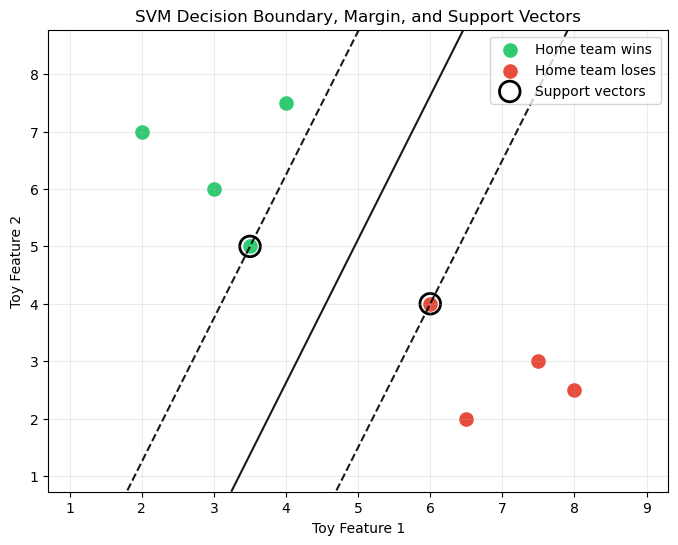

Support vectors:
[[6.  4. ]
 [3.5 5. ]]
Support vectors per class: [1 1]


In [11]:
### 4.1 Visual Explanation of the SVM Boundary

# This toy 2D example shows the SVM idea visually.
# The solid line is the decision boundary,
# the dashed lines are the margins,
# and the circled points are the support vectors.

toy_X = np.array([
    [2.0, 7.0], [3.0, 6.0], [4.0, 7.5], [3.5, 5.0],
    [6.5, 2.0], [7.5, 3.0], [8.0, 2.5], [6.0, 4.0]
])
toy_y = np.array([1, 1, 1, 1, 0, 0, 0, 0])

svm_demo = SVC(kernel='linear', C=1.0)
svm_demo.fit(toy_X, toy_y)

plt.figure(figsize=(8, 6))
plt.scatter(toy_X[toy_y == 1, 0], toy_X[toy_y == 1, 1],
            color='#2ecc71', s=90, label='Home team wins')
plt.scatter(toy_X[toy_y == 0, 0], toy_X[toy_y == 0, 1],
            color='#e74c3c', s=90, label='Home team loses')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0] - 1, xlim[1] + 1, 300)
yy = np.linspace(ylim[0] - 1, ylim[1] + 1, 300)
YY, XX = np.meshgrid(yy, xx)
grid = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_demo.decision_function(grid).reshape(XX.shape)

plt.contour(
    XX, YY, Z,
    colors='black',
    levels=[-1, 0, 1],
    alpha=0.9,
    linestyles=['--', '-', '--']
)

plt.scatter(
    svm_demo.support_vectors_[:, 0],
    svm_demo.support_vectors_[:, 1],
    s=220,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support vectors'
)

plt.title('SVM Decision Boundary, Margin, and Support Vectors')
plt.xlabel('Toy Feature 1')
plt.ylabel('Toy Feature 2')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print('Support vectors:')
print(svm_demo.support_vectors_)
print('Support vectors per class:', svm_demo.n_support_)


## 5. Evaluate Model

In [12]:
y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 40)
print('        SVM — TEST RESULTS')
print('=' * 40)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 40)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Away Wins','Home Wins']))

        SVM — TEST RESULTS
  Accuracy  : 83.60%
  Precision : 85.77%
  Recall    : 86.51%
  F1-Score  : 86.14%
  ROC-AUC   : 0.9224

Classification Report:
              precision    recall  f1-score   support

   Away Wins       0.80      0.79      0.80      2182
   Home Wins       0.86      0.87      0.86      3129

    accuracy                           0.84      5311
   macro avg       0.83      0.83      0.83      5311
weighted avg       0.84      0.84      0.84      5311



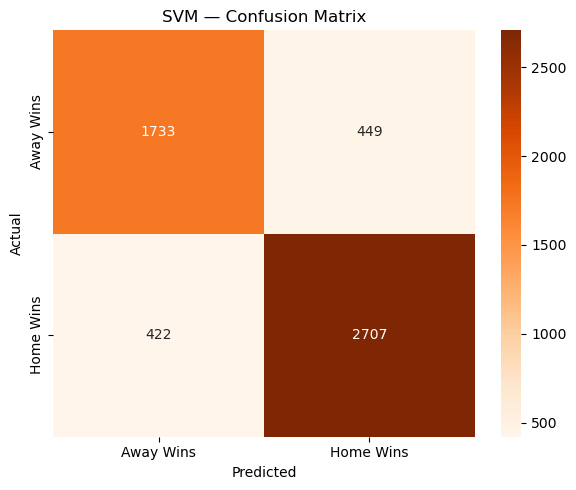

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Away Wins','Home Wins'],
            yticklabels=['Away Wins','Home Wins'])
plt.title('SVM — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

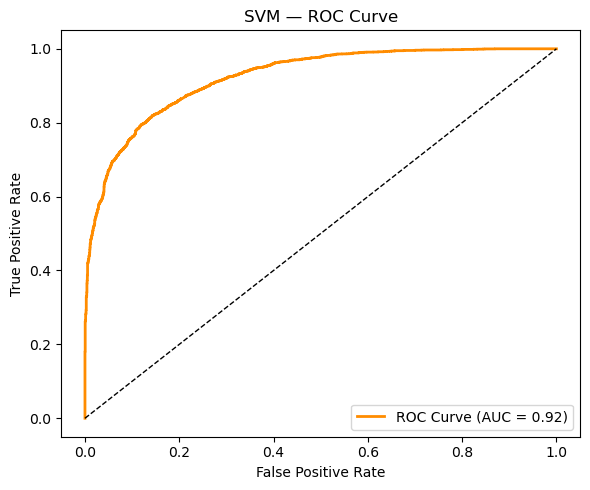

In [14]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('svm_roc_curve.png', dpi=150)
plt.show()

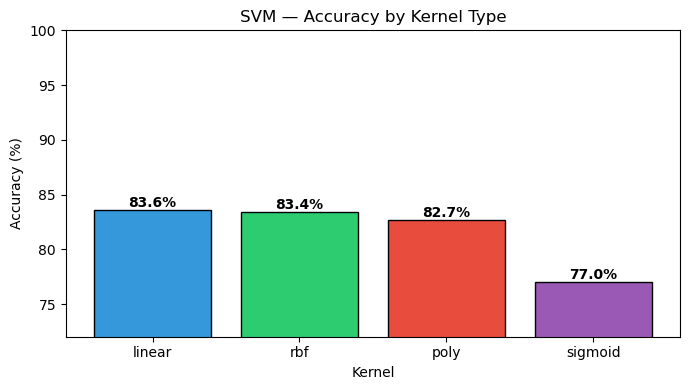

In [15]:
# Compare different SVM kernels
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_scores = []
for k in kernels:
    m = SVC(kernel=k, probability=True, random_state=42)
    m.fit(X_train_scaled, y_train)
    kernel_scores.append(accuracy_score(y_test, m.predict(X_test_scaled)) * 100)

plt.figure(figsize=(7,4))
plt.bar(kernels, kernel_scores, color=['#3498db','#2ecc71','#e74c3c','#9b59b6'], edgecolor='black')
plt.title('SVM — Accuracy by Kernel Type')
plt.ylabel('Accuracy (%)')
plt.xlabel('Kernel')
plt.ylim(min(kernel_scores)-5, 100)
for i, v in enumerate(kernel_scores):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_kernel_comparison.png', dpi=150)
plt.show()

In [16]:
# Cross-validation
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy (5-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

Cross-Validation Accuracy (5-fold): 84.22% ± 0.53%


## SUMMARY

**Key Observations:**
- SVM finds the optimal hyperplane that maximizes the margin between classes.
- The RBF kernel is most suitable for non-linearly separable data.
- SVM is sensitive to feature scaling — StandardScaler is essential.
- The C parameter controls the trade-off between margin width and classification error.
- GridSearchCV helped identify the best kernel and regularization parameters.


## LIVE PREDICTION UTILITY
Use this section to demonstrate the model's prediction on a single game scenario.

In [17]:
import numpy as np
import pandas as pd

# 1. Select a random game from the test set for demonstration
random_idx = np.random.randint(0, len(X_test))
sample_game = X_test.iloc[random_idx]
actual_result = y_test.iloc[random_idx]

print('--- Game Scenario Features ---')
print(sample_game)
print('-' * 30)

# 2. Transform the sample for prediction
# Note: scaler.transform expects a 2D array-like input
sample_scaled = scaler.transform([sample_game.values])

# 3. Make prediction
# Automatically find the available model variable
model = None
for var_name in ['best_rf', 'best_svm', 'knn_best', 'best_knn', 'rf_model', 'svm_model', 'knn_model']:
    if var_name in globals():
        model = globals()[var_name]
        break

if model is None:
    print("Error: No trained model found in global scope.")
else:
    prediction = model.predict(sample_scaled)[0]
    proba = model.predict_proba(sample_scaled)[0]

    # 4. Display Results
    print(f'\n[VIVA DEMO RESULTS]')
    if prediction == 1:
        print('>>> PREDICTION: HOME TEAM WINS! 🏀')
        print(f'Confidence Score: {proba[1]*100:.2f}%')
    else:
        print('>>> PREDICTION: AWAY TEAM WINS! 🏆')
        print(f'Confidence Score: {proba[0]*100:.2f}%')

    result_text = "Home Win" if actual_result == 1 else "Away Win"
    status = "✅ CORRECT" if prediction == actual_result else "❌ INCORRECT"
    print(f'Actual Result: {result_text} ({status})')

--- Game Scenario Features ---
FG_PCT_home      0.373
FT_PCT_home      0.813
FG3_PCT_home     0.500
AST_home        18.000
REB_home        39.000
FG_PCT_away      0.425
FT_PCT_away      0.667
FG3_PCT_away     0.286
AST_away        18.000
REB_away        42.000
Name: 18881, dtype: float64
------------------------------

[VIVA DEMO RESULTS]
>>> PREDICTION: HOME TEAM WINS! 🏀
Confidence Score: 57.73%
Actual Result: Away Win (❌ INCORRECT)
